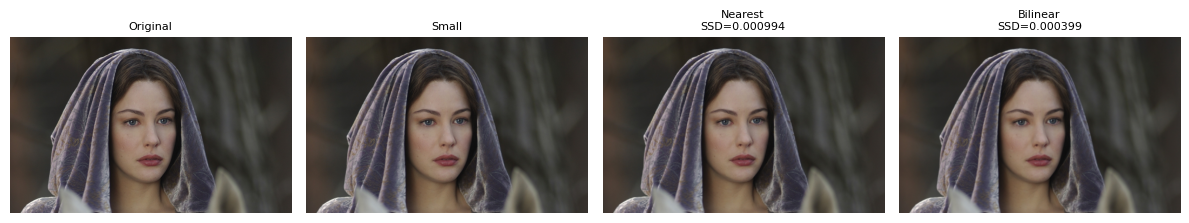

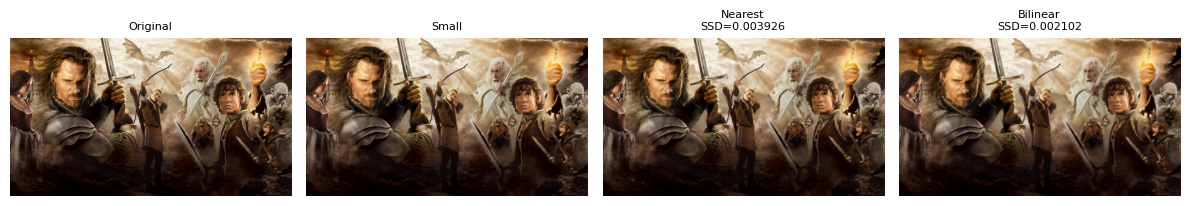

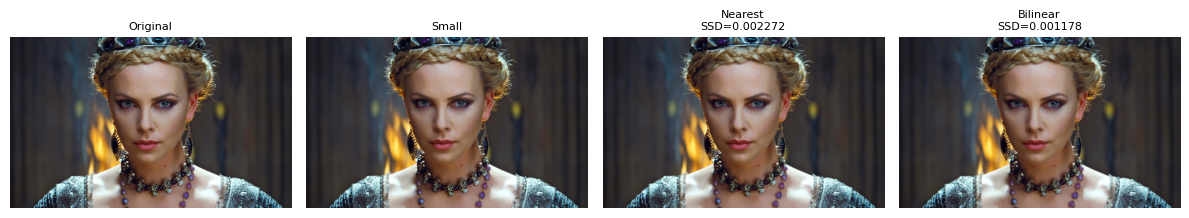

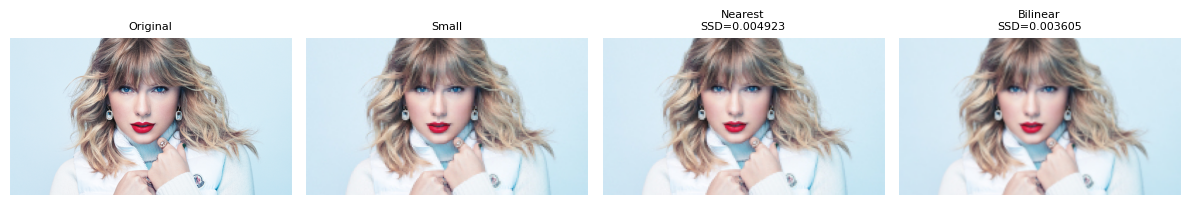

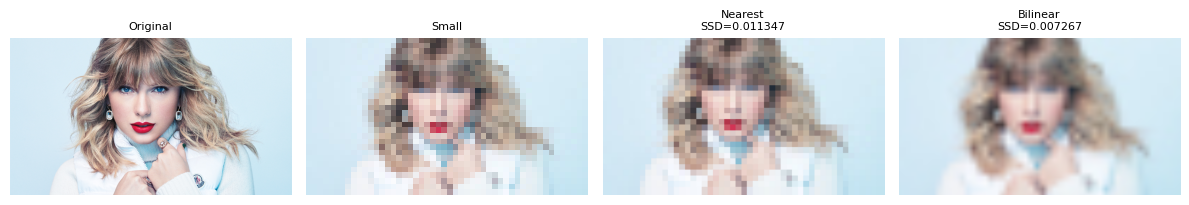


Normalized SSD Results
----------------------------------------
/content/input_Arwen.png
  Nearest Neighbor SSD : 0.000994
  Bilinear SSD         : 0.000399

/content/input_LOR.png
  Nearest Neighbor SSD : 0.003926
  Bilinear SSD         : 0.002102

/content/input_queen.png
  Nearest Neighbor SSD : 0.002272
  Bilinear SSD         : 0.001178

/content/input_taylor.jpg
  Nearest Neighbor SSD : 0.004923
  Bilinear SSD         : 0.003605

/content/input_taylor.jpg
  Nearest Neighbor SSD : 0.011347
  Bilinear SSD         : 0.007267



In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os


# -----------------------------------
# Helper: nearest-neighbor interpolation
# -----------------------------------
def resize_nearest(image, new_h, new_w):
    h, w = image.shape[:2]

    if image.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=image.dtype)
    else:
        output = np.zeros((new_h, new_w, image.shape[2]), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            src_x = int(round(i * (h / new_h)))
            src_y = int(round(j * (w / new_w)))

            src_x = min(src_x, h - 1)
            src_y = min(src_y, w - 1)

            output[i, j] = image[src_x, src_y]

    return output


# -----------------------------------
# Helper: bilinear interpolation
# -----------------------------------
def resize_bilinear(image, new_h, new_w):
    h, w = image.shape[:2]

    if image.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=np.float64)
    else:
        output = np.zeros((new_h, new_w, image.shape[2]), dtype=np.float64)

    for i in range(new_h):
        for j in range(new_w):
            x = i * (h - 1) / (new_h - 1) if new_h > 1 else 0
            y = j * (w - 1) / (new_w - 1) if new_w > 1 else 0

            x1 = int(np.floor(x))
            y1 = int(np.floor(y))
            x2 = min(x1 + 1, h - 1)
            y2 = min(y1 + 1, w - 1)

            dx = x - x1
            dy = y - y1

            top = (1 - dy) * image[x1, y1] + dy * image[x1, y2]
            bottom = (1 - dy) * image[x2, y1] + dy * image[x2, y2]
            value = (1 - dx) * top + dx * bottom

            output[i, j] = value

    return np.clip(output, 0, 255).astype(image.dtype)


# -----------------------------------
# Main zoom function
# -----------------------------------
def zoom_image(image, scale_factor, method="nearest"):
    h, w = image.shape[:2]
    new_h = int(round(h * scale_factor))
    new_w = int(round(w * scale_factor))

    if method == "nearest":
        return resize_nearest(image, new_h, new_w)
    elif method == "bilinear":
        return resize_bilinear(image, new_h, new_w)
    else:
        raise ValueError("Method must be 'nearest' or 'bilinear'")


# -----------------------------------
# Normalized SSD
# -----------------------------------
def normalized_ssd(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    ssd = np.sum((img1 - img2) ** 2)
    norm = img1.size * (255 ** 2)

    return ssd / norm


# -----------------------------------
# Load image pairs
# -----------------------------------
pairs = [
    ("/content/input_Arwen.png", "/content/input_Arwen_small.png"),
    ("/content/input_LOR.png", "/content/input_LOR_small.png"),
    ("/content/input_queen.png", "/content/input_queen_small.png"),
    ("/content/input_taylor.jpg", "/content/input_taylor_small.jpg"),
    ("/content/input_taylor.jpg", "/content/input_taylor_very_small.jpg"),
]

os.makedirs("q7_outputs", exist_ok=True)

results = []

for large_path, small_path in pairs:
    original = cv.imread(large_path)
    small = cv.imread(small_path)

    if original is None or small is None:
        print(f"Could not load pair: {large_path}, {small_path}")
        continue

    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
    small_rgb = cv.cvtColor(small, cv.COLOR_BGR2RGB)

    H, W = original_rgb.shape[:2]
    h, w = small_rgb.shape[:2]

    # scale factor needed to match original size
    scale_h = H / h
    scale_w = W / w

    # use direct target size instead of only factor
    nearest_img = resize_nearest(small_rgb, H, W)
    bilinear_img = resize_bilinear(small_rgb, H, W)

    # SSD
    ssd_nearest = normalized_ssd(original_rgb, nearest_img)
    ssd_bilinear = normalized_ssd(original_rgb, bilinear_img)

    results.append((large_path, ssd_nearest, ssd_bilinear))

    # save outputs

    # Fix: Use os.path.basename to get only the filename before splitext
    large_name = os.path.splitext(os.path.basename(large_path))[0]
    small_name = os.path.splitext(os.path.basename(small_path))[0]
    pair_name = f"{large_name}_{small_name}"

    cv.imwrite(
        f"q7_outputs/{pair_name}_nearest.png",
        cv.cvtColor(nearest_img, cv.COLOR_RGB2BGR),
    )
    cv.imwrite(
        f"q7_outputs/{pair_name}_bilinear.png",
        cv.cvtColor(bilinear_img, cv.COLOR_RGB2BGR),
    )

    # show compact comparison
    plt.figure(figsize=(12, 3))

    plt.subplot(1, 4, 1)
    plt.imshow(original_rgb)
    plt.title("Original", fontsize=8)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(small_rgb)
    plt.title("Small", fontsize=8)
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(nearest_img)
    plt.title(f"Nearest\nSSD={ssd_nearest:.6f}", fontsize=8)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(bilinear_img)
    plt.title(f"Bilinear\nSSD={ssd_bilinear:.6f}", fontsize=8)
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"q7_outputs/{pair_name}_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


# -----------------------------------
# Print final SSD summary
# -----------------------------------
print("\nNormalized SSD Results")
print("-" * 40)
for name, ssd_n, ssd_b in results:
    print(f"{name}")
    print(f"  Nearest Neighbor SSD : {ssd_n:.6f}")
    print(f"  Bilinear SSD         : {ssd_b:.6f}")
    print()